Here is your **full camera code with detailed comments**, including:

* what each line does
* why it exists
* what changed for the shadow acne fix
* what was the old version before

---

# Full Camera Code (commented)

```python
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer
import random


class Camera:

    def __init__(self):

        # Width / Height ratio
        self.aspect_ratio = 16 / 9

        # Total horizontal pixels
        self.image_width = 400

        # Number of rays per pixel
        # More samples = less noise
        self.samples_per_pixel = 100

        # Maximum ray bounces
        # Prevent infinite recursion
        self.max_depth = 50

    def initialize(self):

        # Compute image height using aspect ratio
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        # Safety: minimum 1 pixel
        if self.image_height < 1:
            self.image_height = 1

        # Used to average all samples later
        # Formula:
        # final_color = total_color / samples
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # Camera location (origin)
        self.center = Vec3(0, 0, 0)

        # Distance from camera to viewport
        focal_length = 1.0

        # Physical viewport height
        viewport_height = 2.0

        # Maintain aspect ratio
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # Horizontal axis of viewport
        viewport_u = Vec3(
            viewport_width, 0, 0
        )

        # Vertical axis of viewport
        # Negative y because image goes top -> bottom
        viewport_v = Vec3(
            0, -viewport_height, 0
        )

        # Size of one pixel horizontally
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        # Size of one pixel vertically
        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # Top-left corner of viewport
        # Formula:
        # center - focal - half_u - half_v
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # Exact center of first pixel
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u
                + self.pixel_delta_v
            )
        )

    def sample_square(self):

        # Random subpixel offset for anti-aliasing
        # Range: [-0.5, +0.5]
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):

        # Get random point inside pixel
        offset = self.sample_square()

        # Move to randomized pixel location
        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # Direction from camera to pixel
        ray_direction = (
            pixel_sample - self.center
        )

        # Create ray
        return Ray(
            self.center,
            ray_direction
        )

    def ray_color(self, r, world, depth):

        # Stop bouncing if limit reached
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ==========================================
        # SHADOW ACNE FIX (CHANGE #1)
        # ==========================================
        #
        # OLD:
        # world.hit(r, Interval(0, INFINITY), rec)
        #
        # PROBLEM:
        # Allows tiny self-hit at t ≈ 0
        #
        # NEW:
        # Start checking from t = 0.001
        #
        # Formula:
        # t ∈ [ε, ∞)
        #
        # Purpose:
        # Ignore fake intersections caused by
        # floating point errors.
        # ==========================================
        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):

            # Random diffuse bounce
            direction = random_on_hemisphere(
                rec.normal
            )

            # ==========================================
            # SHADOW ACNE FIX (CHANGE #2)
            # ==========================================
            #
            # OLD:
            # scattered_ray = Ray(rec.p, direction)
            #
            # PROBLEM:
            # rec.p may be slightly inside object
            #
            # NEW:
            # Move ray origin a tiny distance outward
            #
            # Formula:
            # P' = P + εN
            #
            # P = hit point
            # N = surface normal
            # ε = small offset
            #
            # Purpose:
            # Start new ray above the surface
            # ==========================================
            epsilon = 0.001

            scattered_origin = (
                rec.p
                + epsilon * rec.normal
            )

            # Create scattered ray
            scattered_ray = Ray(
                scattered_origin,
                direction
            )

            # Recursive bounce
            #
            # Formula:
            # color = 0.5 × next_bounce
            #
            # 0.5 means lose energy each bounce
            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        # Background color if no hit

        # Normalize direction
        unit_dir = unit_vector(
            r.direction()
        )

        # Convert y into blend value
        t = 0.5 * (
            unit_dir.y + 1.0
        )

        # Linear interpolation (lerp)
        #
        # Formula:
        # color = (1−t)A + tB
        #
        # White at bottom
        # Blue at top
        return (
            (1.0 - t)
            * Vec3(1, 1, 1)
            + t
            * Vec3(0.5, 0.7, 1.0)
        )

    def render(self, world):

        # Setup camera
        self.initialize()

        # Open output image
        with open("output.ppm", "w") as f:

            # Write PPM header
            f.write(
                f"P3\n"
                f"{self.image_width} "
                f"{self.image_height}\n"
                f"255\n"
            )

            # Loop through every row
            for j in tqdm(
                range(self.image_height)
            ):

                # Loop through every column
                for i in range(
                    self.image_width
                ):

                    # Start black
                    pixel_color = Vec3(
                        0, 0, 0
                    )

                    # Multi-sampling loop
                    for _ in range(
                        self.samples_per_pixel
                    ):

                        # Create ray
                        r = self.get_ray(i, j)

                        # Trace ray
                        pixel_color += (
                            self.ray_color(
                                r,
                                world,
                                self.max_depth
                            )
                        )

                    # Average all samples
                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    # Convert [0,1] -> [0,255]
                    ir = int(
                        255.999 * pixel_color.x
                    )

                    ig = int(
                        255.999 * pixel_color.y
                    )

                    ib = int(
                        255.999 * pixel_color.z
                    )

                    # Write pixel
                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):

        # Open rendered image
        return image_viewer("output.ppm")
```

---

# What changed from before?

| Before                  | After                                    | Why                  |
| ----------------------- | ---------------------------------------- | -------------------- |
| `Interval(0, INFINITY)` | `Interval(0.001, INFINITY)`              | ignore fake self-hit |
| `Ray(rec.p, direction)` | `Ray(rec.p + epsilon*normal, direction)` | push ray outside     |
| self-hit at $t≈0$       | no self-hit                              | removes shadow acne  |

---

# Core formulas used

Ray:

$$
R(t)=O+tD
$$

Hit point:

$$
P=O+tD
$$

Offset:

$$
P'=P+\epsilon N
$$

Diffuse bounce:

$$
D' = random(N)
$$

Energy loss:

$$
L=0.5L'
$$

Background interpolation:

$$
(1-t)A+tB
$$

These are the main mathematical steps driving this renderer.


# Code - Fixing Shadow Acne

In [3]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
import psutil
import GPUtil
import os

In [4]:
def system_monitor():

    # CPU percentage
    cpu_percent = psutil.cpu_percent()

    # RAM usage
    ram = psutil.virtual_memory()

    # CPU temperature (Linux mostly)
    try:
        temps = psutil.sensors_temperatures()
        cpu_temp = temps["coretemp"][0].current
    except:
        cpu_temp = "N/A"

    # GPU info
    try:
        gpus = GPUtil.getGPUs()

        for gpu in gpus:
            gpu_load = gpu.load * 100
            gpu_temp = gpu.temperature
            gpu_memory = gpu.memoryUsed

    except:
        gpu_load = "N/A"
        gpu_temp = "N/A"
        gpu_memory = "N/A"

    print(
        f"CPU: {cpu_percent}% | "
        f"RAM: {ram.percent}% | "
        f"CPU Temp: {cpu_temp}°C | "
        f"GPU Load: {gpu_load}% | "
        f"GPU Temp: {gpu_temp}°C | "
        f"GPU VRAM: {gpu_memory}MB"
    )

In [9]:
import psutil
import GPUtil


def system_monitor():

    cpu_percent = psutil.cpu_percent()
    ram_percent = psutil.virtual_memory().percent

    # CPU temp (may fail on Windows)
    try:
        temps = psutil.sensors_temperatures()
        cpu_temp = temps["coretemp"][0].current
    except:
        cpu_temp = "N/A"

    # GPU info
    try:
        gpus = GPUtil.getGPUs()

        if gpus:
            gpu = gpus[0]

            gpu_load = gpu.load * 100
            gpu_temp = gpu.temperature
            gpu_memory = gpu.memoryUsed
        else:
            gpu_load = "N/A"
            gpu_temp = "N/A"
            gpu_memory = "N/A"

    except:
        gpu_load = "N/A"
        gpu_temp = "N/A"
        gpu_memory = "N/A"

    return {
        "CPU": f"{cpu_percent:.1f}%",
        "RAM": f"{ram_percent:.1f}%",
        "CPU Temp": f"{cpu_temp}",
        "GPU Temp": f"{gpu_temp}°C",
        "VRAM": f"{gpu_memory}MB"
    }

In [10]:
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_on_hemisphere
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer
import random


class Camera:

    def __init__(self):

        # Width / Height ratio
        self.aspect_ratio = 16 / 9

        # Total horizontal pixels
        self.image_width = 400

        # Number of rays per pixel
        # More samples = less noise
        self.samples_per_pixel = 100

        # Maximum ray bounces
        # Prevent infinite recursion
        self.max_depth = 50

    def initialize(self):

        # Compute image height using aspect ratio
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        # Safety: minimum 1 pixel
        if self.image_height < 1:
            self.image_height = 1

        # Used to average all samples later
        # Formula:
        # final_color = total_color / samples
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # Camera location (origin)
        self.center = Vec3(0, 0, 0)

        # Distance from camera to viewport
        focal_length = 1.0

        # Physical viewport height
        viewport_height = 2.0

        # Maintain aspect ratio
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # Horizontal axis of viewport
        viewport_u = Vec3(
            viewport_width, 0, 0
        )

        # Vertical axis of viewport
        # Negative y because image goes top -> bottom
        viewport_v = Vec3(
            0, -viewport_height, 0
        )

        # Size of one pixel horizontally
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        # Size of one pixel vertically
        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # Top-left corner of viewport
        # Formula:
        # center - focal - half_u - half_v
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # Exact center of first pixel
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u
                + self.pixel_delta_v
            )
        )

    def sample_square(self):

        # Random subpixel offset for anti-aliasing
        # Range: [-0.5, +0.5]
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):

        # Get random point inside pixel
        offset = self.sample_square()

        # Move to randomized pixel location
        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # Direction from camera to pixel
        ray_direction = (
            pixel_sample - self.center
        )

        # Create ray
        return Ray(
            self.center,
            ray_direction
        )

    def ray_color(self, r, world, depth):

        # Stop bouncing if limit reached
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ==========================================
        # SHADOW ACNE FIX (CHANGE #1)
        # ==========================================
        #
        # OLD:
        # world.hit(r, Interval(0, INFINITY), rec)
        #
        # PROBLEM:
        # Allows tiny self-hit at t ≈ 0
        #
        # NEW:
        # Start checking from t = 0.001
        #
        # Formula:
        # t ∈ [ε, ∞)
        #
        # Purpose:
        # Ignore fake intersections caused by
        # floating point errors.
        # ==========================================
        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):

            # Random diffuse bounce
            direction = random_on_hemisphere(
                rec.normal
            )

            # ==========================================
            # SHADOW ACNE FIX (CHANGE #2)
            # ==========================================
            #
            # OLD:
            # scattered_ray = Ray(rec.p, direction)
            #
            # PROBLEM:
            # rec.p may be slightly inside object
            #
            # NEW:
            # Move ray origin a tiny distance outward
            #
            # Formula:
            # P' = P + εN
            #
            # P = hit point
            # N = surface normal
            # ε = small offset
            #
            # Purpose:
            # Start new ray above the surface
            # ==========================================
            epsilon = 0.001

            scattered_origin = (
                rec.p
                + epsilon * rec.normal
            )

            # Create scattered ray
            scattered_ray = Ray(
                scattered_origin,
                direction
            )

            # Recursive bounce
            #
            # Formula:
            # color = 0.5 × next_bounce
            #
            # 0.5 means lose energy each bounce
            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        # Background color if no hit

        # Normalize direction
        unit_dir = unit_vector(
            r.direction()
        )

        # Convert y into blend value
        t = 0.5 * (
            unit_dir.y + 1.0
        )

        # Linear interpolation (lerp)
        #
        # Formula:
        # color = (1−t)A + tB
        #
        # White at bottom
        # Blue at top
        return (
            (1.0 - t)
            * Vec3(1, 1, 1)
            + t
            * Vec3(0.5, 0.7, 1.0)
        )

    def render(self, world):

        # Setup camera
        self.initialize()

        # Open output image
        with open("output.ppm", "w") as f:

            # Write PPM header
            f.write(
                f"P3\n"
                f"{self.image_width} "
                f"{self.image_height}\n"
                f"255\n"
            )

            # Loop through every row
            pbar = tqdm(range(self.image_height))

            for j in pbar:

                # update every 5 rows
                if j % 5 == 0:
                   stats = system_monitor()
                   pbar.set_postfix(stats)

                # Loop through every column
                for i in range(
                    self.image_width
                ):

                    # Start black
                    pixel_color = Vec3(
                        0, 0, 0
                    )

                    # Multi-sampling loop
                    for _ in range(
                        self.samples_per_pixel
                    ):

                        # Create ray
                        r = self.get_ray(i, j)

                        # Trace ray
                        pixel_color += (
                            self.ray_color(
                                r,
                                world,
                                self.max_depth
                            )
                        )

                    # Average all samples
                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    # Convert [0,1] -> [0,255]
                    ir = int(
                        255.999 * pixel_color.x
                    )

                    ig = int(
                        255.999 * pixel_color.y
                    )

                    ib = int(
                        255.999 * pixel_color.z
                    )

                    # Write pixel
                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):

        # Open rendered image
        return image_viewer("output.ppm")

In [12]:
from util.sphere import Sphere
#from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:59<00:00,  1.06s/it, CPU=44.4%, RAM=78.9%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=690.0MB]


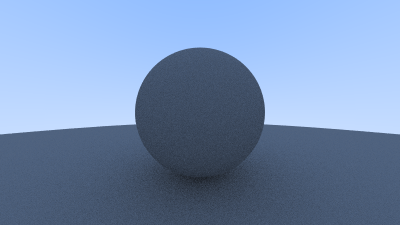

In [13]:
cam.show()


# Code Reduce

In [14]:
from util.sphere import Sphere
from util.camera_diff3 import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [04:09<00:00,  1.11s/it, CPU=32.2%, RAM=76.9%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=638.0MB, GPU Load=nan]


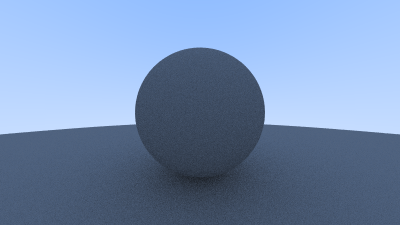

In [15]:
cam.show()